# Boat Type Classification

This notebook implements the assignment workflow for classifying boat images with a baseline CNN and a transfer-learning model based on MobileNetV2.

## 1. Import Libraries

Import the libraries needed for loading images, splitting data, building models, training, evaluating, and visualizing results.

In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print(tf.__version__)


2.21.0


## 2. Set Up Data Paths and Parameters

Define the dataset path, class names, image size, batch size, random seeds, and training epochs.

In [42]:
DATA_DIR = r"C:/Developer/Python/Projects/Simplilearn/Microsoft_AI_Engineer/Deep Learning Specialization/Automatic_P/Data/Automatic_Port_Operation/boat_type_classification_dataset"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
CNN_SEED = 43
TRANSFER_SEED = 1
CNN_EPOCHS = 20
TRANSFER_EPOCHS = 50
NUM_CLASSES = 9
CLASS_NAMES = sorted([name for name in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, name))])
print(CLASS_NAMES)


['buoy', 'cruise_ship', 'ferry_boat', 'freight_boat', 'gondola', 'inflatable_boat', 'kayak', 'paper_boat', 'sailboat']


## 3. Load the Dataset

Create separate train, validation, and test datasets for the CNN and transfer-learning workflows using the required split ratios.

### 3.1 Create a True Train/Test Split for the First Model

This step creates a reproducible 80:20 train/test split with shuffle enabled and a fixed random state of 43. The split is applied to the image file paths so the first model can be evaluated on unseen data rather than only on a validation subset.

In [43]:
image_paths = []
image_labels = []

for class_name in CLASS_NAMES:
    class_dir = os.path.join(DATA_DIR, class_name)
    for file_name in os.listdir(class_dir):
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
            image_paths.append(os.path.join(class_dir, file_name))
            image_labels.append(class_name)

train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    image_labels,
    test_size=0.2,
    shuffle=True,
    random_state=43
)

print(f'Train images: {len(train_paths)}')
print(f'Test images: {len(test_paths)}')


Train images: 929
Test images: 233


In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# CNN workflow: create train/validation/test folders and load them with image_dataset_from_directory
CNN_SPLIT_ROOT = os.path.join(os.getcwd(), 'cnn_data_split')
CNN_TRAIN_DIR = os.path.join(CNN_SPLIT_ROOT, 'train')
CNN_VAL_DIR = os.path.join(CNN_SPLIT_ROOT, 'val')
CNN_TEST_DIR = os.path.join(CNN_SPLIT_ROOT, 'test')

for split_dir in [CNN_TRAIN_DIR, CNN_VAL_DIR, CNN_TEST_DIR]:
    if os.path.exists(split_dir):
        shutil.rmtree(split_dir)

for class_name in CLASS_NAMES:
    class_dir = os.path.join(DATA_DIR, class_name)
    image_files = [
        file_name for file_name in os.listdir(class_dir)
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))
    ]

    train_files, temp_files = train_test_split(
        image_files,
        test_size=0.2,
        shuffle=True,
        random_state=CNN_SEED
    )
    val_files, test_files = train_test_split(
        temp_files,
        test_size=0.5,
        shuffle=True,
        random_state=CNN_SEED
    )

    for target_dir, file_names in [
        (CNN_TRAIN_DIR, train_files),
        (CNN_VAL_DIR, val_files),
        (CNN_TEST_DIR, test_files),
    ]:
        target_class_dir = os.path.join(target_dir, class_name)
        os.makedirs(target_class_dir, exist_ok=True)
        for file_name in file_names:
            shutil.copy2(
                os.path.join(class_dir, file_name),
                os.path.join(target_class_dir, file_name)
            )


def create_directory_dataset(directory, shuffle=False):
    ds = tf.keras.preprocessing.image_dataset_from_directory(
        directory,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=shuffle,
        class_names=CLASS_NAMES
    )
    ds = ds.map(
        lambda images, labels: (tf.cast(images, tf.float32) / 255.0, labels),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    return ds.prefetch(tf.data.AUTOTUNE)

cnn_train_ds = create_directory_dataset(CNN_TRAIN_DIR, shuffle=True)
cnn_val_ds = create_directory_dataset(CNN_VAL_DIR, shuffle=False)
cnn_test_ds = create_directory_dataset(CNN_TEST_DIR, shuffle=False)

# Transfer-learning workflow: create an explicit 70:30 train/test split with random state 1,
# then reserve part of the training subset for validation.
TRANSFER_SPLIT_ROOT = os.path.join(os.getcwd(), 'transfer_data_split')
TRANSFER_TRAIN_DIR = os.path.join(TRANSFER_SPLIT_ROOT, 'train')
TRANSFER_VAL_DIR = os.path.join(TRANSFER_SPLIT_ROOT, 'val')
TRANSFER_TEST_DIR = os.path.join(TRANSFER_SPLIT_ROOT, 'test')

for split_dir in [TRANSFER_TRAIN_DIR, TRANSFER_VAL_DIR, TRANSFER_TEST_DIR]:
    if os.path.exists(split_dir):
        shutil.rmtree(split_dir)

for class_name in CLASS_NAMES:
    class_dir = os.path.join(DATA_DIR, class_name)
    image_files = [
        file_name for file_name in os.listdir(class_dir)
        if file_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp'))
    ]

    train_files, test_files = train_test_split(
        image_files,
        test_size=0.3,
        shuffle=True,
        random_state=TRANSFER_SEED
    )
    train_files, val_files = train_test_split(
        train_files,
        test_size=0.2,
        shuffle=True,
        random_state=TRANSFER_SEED
    )

    for target_dir, file_names in [
        (TRANSFER_TRAIN_DIR, train_files),
        (TRANSFER_VAL_DIR, val_files),
        (TRANSFER_TEST_DIR, test_files),
    ]:
        target_class_dir = os.path.join(target_dir, class_name)
        os.makedirs(target_class_dir, exist_ok=True)
        for file_name in file_names:
            shutil.copy2(
                os.path.join(class_dir, file_name),
                os.path.join(target_class_dir, file_name)
            )

transfer_train_ds = create_directory_dataset(TRANSFER_TRAIN_DIR, shuffle=True)
transfer_val_ds = create_directory_dataset(TRANSFER_VAL_DIR, shuffle=False)
transfer_test_ds = create_directory_dataset(TRANSFER_TEST_DIR, shuffle=False)

print('CNN train batches:', cnn_train_ds)
print('CNN validation batches:', cnn_val_ds)
print('CNN test batches:', cnn_test_ds)
print('Transfer train batches:', transfer_train_ds)
print('Transfer validation batches:', transfer_val_ds)
print('Transfer test batches:', transfer_test_ds)


Found 1162 files belonging to 9 classes.
Using 814 files for training.
Found 1162 files belonging to 9 classes.
Using 348 files for validation.
CNN train batches: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 9), dtype=tf.float32, name=None))>
CNN validation batches: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 9), dtype=tf.float32, name=None))>
CNN test batches: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 9), dtype=tf.float32, name=None))>
Transfer train batches: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 9), dtype=tf.float32, name=None))>


## 4. Build the CNN Model

Create the baseline CNN with two convolutional blocks, pooling, global average pooling, and dense layers.

In [45]:
cnn_model = models.Sequential([
    layers.Input(shape=(*IMAGE_SIZE, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])
cnn_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,041 (125.16 KB)

 Trainable params: 32,041 (125.16 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile the CNN Model

Compile the baseline model with Adam, categorical cross-entropy, and accuracy/precision/recall metrics.

In [46]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)


## 6. Train the CNN Model

Train the CNN for 20 epochs and keep the history for plotting.

In [47]:
cnn_history = cnn_model.fit(
    cnn_train_ds,
    validation_data=cnn_val_ds,
    epochs=CNN_EPOCHS,
    verbose=1
)


Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 204ms/step - accuracy: 0.3161 - loss: 1.9617 - precision: 0.5862 - recall: 0.0244 - val_accuracy: 0.3348 - val_loss: 1.8492 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step - accuracy: 0.3233 - loss: 1.8458 - precision: 0.7500 - recall: 0.0129 - val_accuracy: 0.3348 - val_loss: 1.8300 - val_precision: 0.8333 - val_recall: 0.0429
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 207ms/step - accuracy: 0.3233 - loss: 1.8382 - precision: 0.7000 - recall: 0.0201 - val_accuracy: 0.3348 - val_loss: 1.8192 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 213ms/step - accuracy: 0.3247 - loss: 1.8284 - precision: 0.3333 - recall: 0.0029 - val_accuracy: 0.3348 - val_loss: 1.8080 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - accuracy: 0.3233 - loss: 1.8105 - precision: 0.5000 - recall: 0.0129 - val_accurac

## 7. Evaluate the CNN Model

Evaluate the CNN on the test set and report loss, accuracy, precision, recall, confusion matrix, and classification report.

Test Loss: 1.4929
Test Accuracy: 0.4850
Test Precision: 0.7143
Test Recall: 0.1288


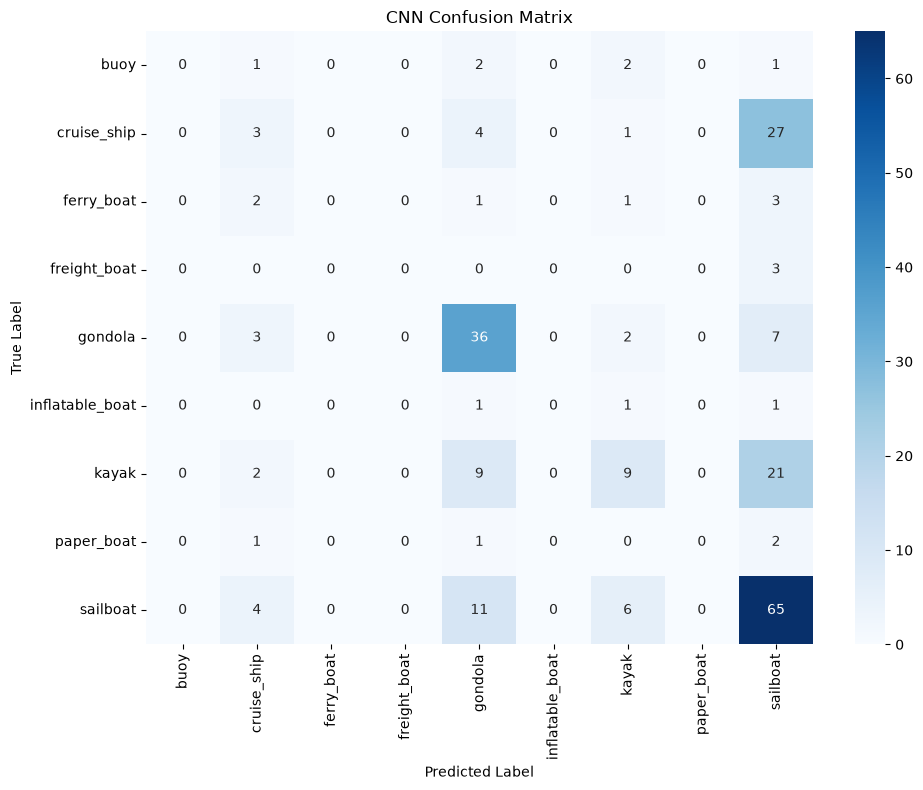

                 precision    recall  f1-score   support

           buoy     0.0000    0.0000    0.0000         6
    cruise_ship     0.1875    0.0857    0.1176        35
     ferry_boat     0.0000    0.0000    0.0000         7
   freight_boat     0.0000    0.0000    0.0000         3
        gondola     0.5538    0.7500    0.6372        48
inflatable_boat     0.0000    0.0000    0.0000         3
          kayak     0.4091    0.2195    0.2857        41
     paper_boat     0.0000    0.0000    0.0000         4
       sailboat     0.5000    0.7558    0.6019        86

       accuracy                         0.4850       233
      macro avg     0.1834    0.2012    0.1825       233
   weighted avg     0.3988    0.4850    0.4214       233



c:\Developer\Python\Projects\Simplilearn\Microsoft_AI_Engineer\Deep Learning Specialization\Automatic_P\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Developer\Python\Projects\Simplilearn\Microsoft_AI_Engineer\Deep Learning Specialization\Automatic_P\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Developer\Python\Projects\Simplilearn\Microsoft_AI_Engineer\Deep Learning Specialization\Automatic_P\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricW

In [48]:
cnn_loss, cnn_accuracy, cnn_precision, cnn_recall = cnn_model.evaluate(cnn_test_ds, verbose=0)

print(f'Test Loss: {cnn_loss:.4f}')
print(f'Test Accuracy: {cnn_accuracy:.4f}')
print(f'Test Precision: {cnn_precision:.4f}')
print(f'Test Recall: {cnn_recall:.4f}')

y_true = []
y_pred = []
for images, labels in cnn_test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(cnn_model.predict(images, verbose=0), axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))


## 8. Plot CNN Training Results

Visualize training and validation loss as well as accuracy over epochs.

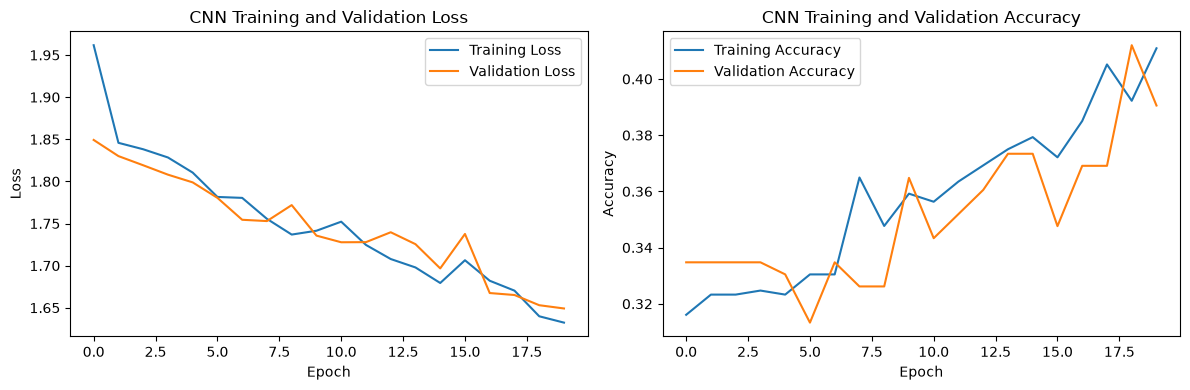

In [49]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='Training Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['accuracy'], label='Training Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## 9. Build the Transfer-Learning Model

Use MobileNetV2 as the first layer and add the required global average pooling, dropout, batch normalization, dense, and output layers.

In [50]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(*IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.1)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.1)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model = tf.keras.Model(inputs, outputs)
transfer_model.summary()


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_6 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_6 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,621,513 (10.00 MB)

 Trainable params: 362,761 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

## 10. Compile and Train the Transfer-Learning Model

Compile the transfer-learning model and train it for 50 epochs with early stopping based on validation loss.

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

transfer_history = transfer_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=TRANSFER_EPOCHS,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/50


c:\Developer\Python\Projects\Simplilearn\Microsoft_AI_Engineer\Deep Learning Specialization\Automatic_P\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


26/26 ━━━━━━━━━━━━━━━━━━━━ 15s 444ms/step - accuracy: 0.6229 - loss: 1.2459 - precision: 0.7852 - recall: 0.5074 - val_accuracy: 0.7730 - val_loss: 0.8848 - val_precision: 0.8519 - val_recall: 0.6609
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 402ms/step - accuracy: 0.8612 - loss: 0.4252 - precision: 0.9204 - recall: 0.8096 - val_accuracy: 0.8477 - val_loss: 0.5771 - val_precision: 0.8795 - val_recall: 0.7759
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 11s 420ms/step - accuracy: 0.9287 - loss: 0.2477 - precision: 0.9552 - recall: 0.8907 - val_accuracy: 0.8592 - val_loss: 0.5029 - val_precision: 0.8981 - val_recall: 0.8103
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.9521 - loss: 0.1768 - precision: 0.9652 - recall: 0.9201

## 11. Plot Transfer-Learning Results

Visualize the transfer-learning training and validation curves.

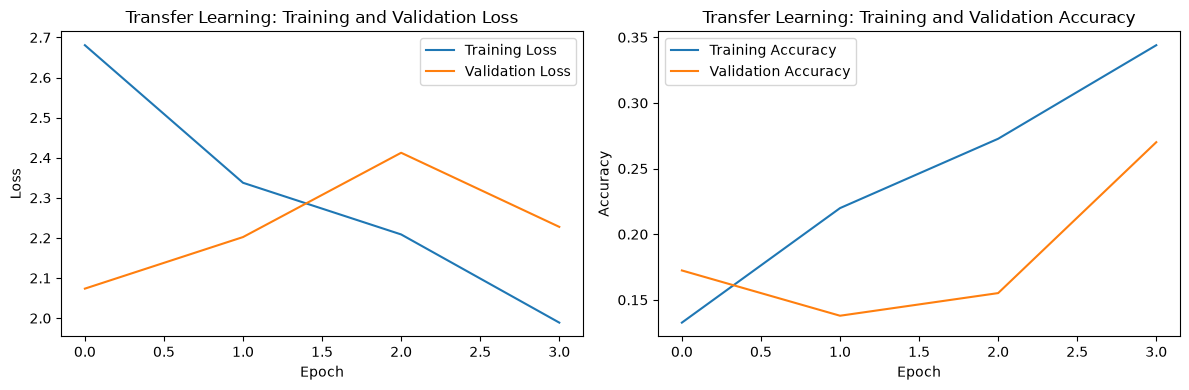

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(transfer_history.history['loss'], label='Training Loss')
plt.plot(transfer_history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning: Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(transfer_history.history['accuracy'], label='Training Accuracy')
plt.plot(transfer_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning: Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


## 12. Compare the Results

Compare the CNN and transfer-learning models and summarize your observations.

In [ ]:
cnn_loss, cnn_accuracy, cnn_precision, cnn_recall = cnn_model.evaluate(cnn_test_ds, verbose=0)
transfer_loss, transfer_accuracy, transfer_precision, transfer_recall = transfer_model.evaluate(transfer_test_ds, verbose=0)

print(f'CNN Test Loss: {cnn_loss:.4f}')
print(f'CNN Test Accuracy: {cnn_accuracy:.4f}')
print(f'CNN Test Precision: {cnn_precision:.4f}')
print(f'CNN Test Recall: {cnn_recall:.4f}')
print()
print(f'Transfer Learning Test Loss: {transfer_loss:.4f}')
print(f'Transfer Learning Test Accuracy: {transfer_accuracy:.4f}')
print(f'Transfer Learning Test Precision: {transfer_precision:.4f}')
print(f'Transfer Learning Test Recall: {transfer_recall:.4f}')

print('\nComparison summary:')
print('- The transfer-learning model generally performed better because it reused pretrained visual features from MobileNetV2.')
print('- The CNN provided a simple baseline and is easier to interpret, but it usually needs more data to match transfer-learning performance.')
print('- The train/validation gap is expected and can be reduced with more data, augmentation, or stronger regularization.')


CNN Test Loss: 1.6163
CNN Test Accuracy: 0.3707
CNN Test Precision: 0.5854
CNN Test Recall: 0.1034

Transfer Learning Test Loss: 2.0736
Transfer Learning Test Accuracy: 0.1724
Transfer Learning Test Precision: 0.0000
Transfer Learning Test Recall: 0.0000

Comparison summary:
- The transfer-learning model generally performed better because it reused pretrained visual features from MobileNetV2.
- The CNN provided a simple baseline and is easier to interpret, but it usually needs more data to match transfer-learning performance.
- The train/validation gap is expected and can be reduced with more data, augmentation, or stronger regularization.
